In [1]:
import pandas as pd
import numpy as np


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sudhirsingh108/data-science-students")
print("Path to dataset files:", path)

100%|██████████| 5.08k/5.08k [00:00<00:00, 7.98MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sudhirsingh108/data-science-students/versions/1


In [3]:
import kagglehub
import pandas as pd
import os

# 1. Download (returns the directory path)
path = kagglehub.dataset_download("sudhirsingh108/data-science-students")

# 2. List files to find the CSV name
files = os.listdir(path)
print("Files in dataset:", files)

# 3. Join the path with the filename (assuming it's the first CSV found)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# 4. Load with Pandas directly
df = pd.read_csv(full_path)

print("\nSuccess! First 5 records:")
print(df.head())

Using Colab cache for faster access to the 'data-science-students' dataset.
Files in dataset: ['data_science_student_marks.csv', '.nfs000000003ac54af500000211']

Success! First 5 records:
   student_id location  age  sql_marks  excel_marks  python_marks  \
0           4   Sydney   24         95           99            87   
1           5    Tokyo   24         99           95            89   
2           6   Berlin   22         72           70            99   
3           7   London   23         97           90            74   
4           8    Tokyo   22         91           71            79   

   power_bi_marks  english_marks  
0              82             75  
1              86             82  
2              79             77  
3              72             85  
4              80             75  


In [4]:
df.shape[0]

497

In [5]:
!pip install basemap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.1
    Uninstalling packaging-26.1:
      Successfully uninstalled packaging-26.1


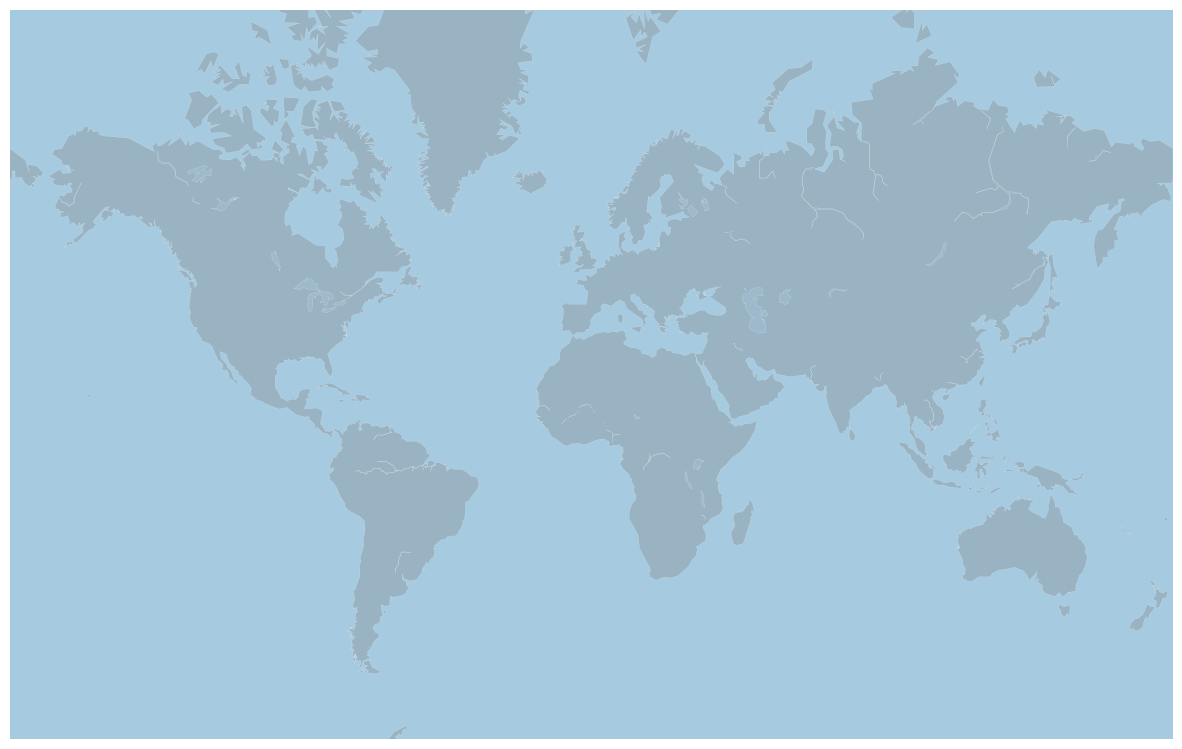

In [6]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

# Set the dimension of the figure
plt.rcParams["figure.figsize"]=15,10;

# Make the background map
m=Basemap(llcrnrlon=-180, llcrnrlat=-65, urcrnrlon=180, urcrnrlat=80, projection='merc');
m.drawmapboundary(fill_color='#A6CAE0', linewidth=0);
m.fillcontinents(color='grey', alpha=0.3);
m.drawcoastlines(linewidth=0.1, color="white");

In [7]:
df

,student_id,location,age,sql_marks,excel_marks,python_marks,power_bi_marks,english_marks
0,4,Sydney,24,95,99,87,82,75
1,5,Tokyo,24,99,95,89,86,82
2,6,Berlin,22,72,70,99,79,77
3,7,London,23,97,90,74,72,85
4,8,Tokyo,22,91,71,79,80,75
...,...,...,...,...,...,...,...,...
492,496,New York,23,71,92,98,78,88
493,497,Los Angeles,20,90,100,90,78,73
494,498,Paris,22,78,80,78,71,70
495,499,Los Angeles,21,96,93,78,78,82


In [8]:
city_counts = df.groupby('location').size().reset_index(name='count')
city_counts

,location,count
0,Berlin,52
1,London,46
2,Los Angeles,60
3,Melbourne,58
4,New York,57
5,Paris,55
6,Sydney,53
7,Tokyo,60
8,Toronto,56


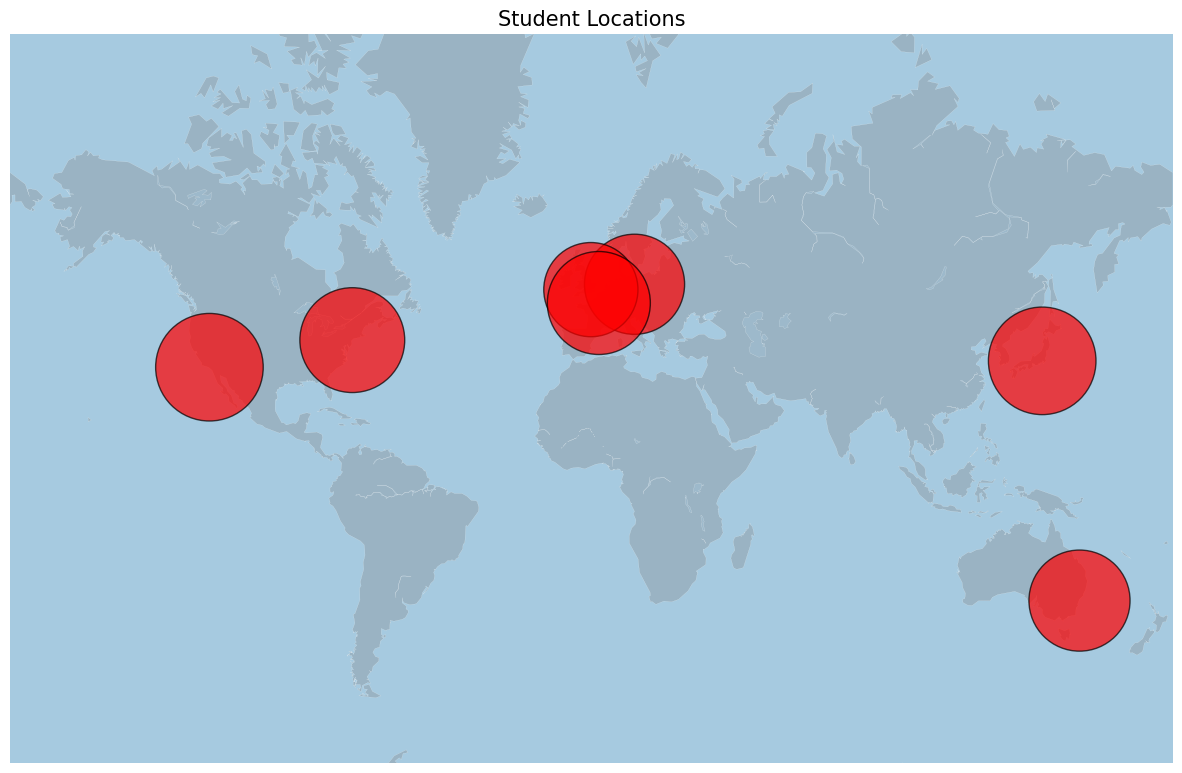

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# 1. Setup Data (Ensure all your CSV cities are in this dictionary)
coords = {
    'Sydney': [151.20, -33.86], 'Tokyo': [139.65, 35.67], 'Berlin': [13.40, 52.52],
    'London': [-0.12, 51.50], 'New York': [-74.00, 40.71], 'Los Angeles': [-118.24, 34.05],
    'Paris': [2.35, 48.85]
}

city_counts = df.groupby('location').size().reset_index(name='count')
city_counts['lon'] = city_counts['location'].map(lambda x: coords.get(x, [None])[0])
city_counts['lat'] = city_counts['location'].map(lambda x: coords.get(x, [None, None])[1])
city_counts = city_counts.dropna()

# 2. Initialize Map
plt.figure(figsize=(15, 10))
m = Basemap(llcrnrlon=-180, llcrnrlat=-65, urcrnrlon=180, urcrnrlat=80, projection='merc')

# 3. Draw Background Layers
m.drawmapboundary(fill_color='#A6CAE0', linewidth=0)
m.fillcontinents(color='grey', alpha=0.3, zorder=1) # Low zorder
m.drawcoastlines(linewidth=0.1, color="white", zorder=1)

# 4. Convert Coordinates and Plot
# IMPORTANT: You must pass lon/lat through 'm' to get map coordinates
x, y = m(city_counts['lon'].values, city_counts['lat'].values)

m.scatter(
    x, y,
    s=city_counts['count'] * 100, # Size based on number of students
    c='red',                      # Bright color to see easily
    alpha=0.7,
    edgecolor='black',
    zorder=5                      # High zorder to stay on top
)

plt.title("Student Locations", fontsize=15)
plt.show()

4/28/2026 (advaned pandas func.)


multi indexes

In [10]:
import pandas as pd
import numpy as np

# Creating a more complex dataframe with multi-index
index = pd.MultiIndex.from_tuples([('New York', 'Q1', 'one'), ('New York', 'Q1', 'two'),
                                   ('Los Angeles', 'Q1', 'one'), ('Los Angeles', 'Q1', 'two'),
                                   ('Chicago', 'Q2', 'one'), ('Chicago', 'Q2', 'two'),
                                   ('New York', 'Q2', 'one'), ('New York', 'Q2', 'two')],
                                  names=['City', 'Quarter', 'ID'])

# Creating random data for Sales, Profit, and Quantity
sales = np.round(np.random.uniform(100, 500, 8), 2)  # Sales between 100 and 500
profit = np.round(np.random.uniform(0, 0.35, 8), 2)     # Profit between 0 and 0.35
quantity = np.random.randint(1, 20, 8)               # Quantity as integers

# Creating the dataframe
df_multi = pd.DataFrame({'Sales': sales, 'Profit(%)': profit, 'Quantity': quantity}, index=index)

print(df_multi)

                          Sales  Profit(%)  Quantity
City        Quarter ID                              
New York    Q1      one  104.05       0.13        14
                    two  440.00       0.16         1
Los Angeles Q1      one  269.30       0.24        15
                    two  361.34       0.17        19
Chicago     Q2      one  330.48       0.27        15
                    two  498.03       0.31        12
New York    Q2      one  472.52       0.13         5
                    two  408.96       0.33        19


In [11]:
df_multi.loc["New York","Q1"]

/tmp/ipykernel_5294/1076528320.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_multi.loc["New York","Q1"]


,Sales,Profit(%),Quantity
ID,,,
one,104.05,0.13,14
two,440.00,0.16,1


In [12]:
df_multi.loc["Chicago","Sales"]
#way2
df_multi.loc["Chicago"]["Sales"]

/tmp/ipykernel_5294/2522600939.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_multi.loc["Chicago","Sales"]


Quarter  ID 
Q2       one    330.48
         two    498.03
Name: Sales, dtype: float64

In [13]:
df_multi.loc[("Chicago","Q2"),'Profit(%)']

/tmp/ipykernel_5294/3753509084.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_multi.loc[("Chicago","Q2"),'Profit(%)']


,Profit(%)
ID,
one,0.27
two,0.31


In [14]:
df_multi.loc[("New York","Q2"),['Profit(%)','Quantity','Sales']]

/tmp/ipykernel_5294/1602439193.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_multi.loc[("New York","Q2"),['Profit(%)','Quantity','Sales']]


,Profit(%),Quantity,Sales
ID,,,
one,0.13,5,472.52
two,0.33,19,408.96


In [15]:
df_multi.loc["New York","Q2"][['Profit(%)','Quantity','Sales']]

/tmp/ipykernel_5294/1101292283.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_multi.loc["New York","Q2"][['Profit(%)','Quantity','Sales']]


,Profit(%),Quantity,Sales
ID,,,
one,0.13,5,472.52
two,0.33,19,408.96


In [16]:
#way 1
print(df_multi.loc["Chicago","Q2"][['Sales']])
#way 2
print(df_multi.loc[("Chicago","Q2"),'Sales'])

      Sales
ID         
one  330.48
two  498.03
ID
one    330.48
two    498.03
Name: Sales, dtype: float64


/tmp/ipykernel_5294/94498161.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  print(df_multi.loc["Chicago","Q2"][['Sales']])
/tmp/ipykernel_5294/94498161.py:4: PerformanceWarning: indexing past lexsort depth may impact performance.
  print(df_multi.loc[("Chicago","Q2"),'Sales'])


In [17]:
df_multi.loc[(slice(None),slice(None),'one'),:]

,,,Sales,Profit(%),Quantity
City,Quarter,ID,,,
New York,Q1,one,104.05,0.13,14
Los Angeles,Q1,one,269.30,0.24,15
Chicago,Q2,one,330.48,0.27,15
New York,Q2,one,472.52,0.13,5


In [18]:
df_multi.loc[df_multi['Sales'] > 300]

Sales  Profit(%)  Quantity
City        Quarter ID                              
New York    Q1      two  440.00       0.16         1
Los Angeles Q1      two  361.34       0.17        19
Chicago     Q2      one  330.48       0.27        15
                    two  498.03       0.31        12
New York    Q2      one  472.52       0.13         5
                    two  408.96       0.33        19

In [19]:
df_multi.loc[df_multi['Quantity'] < 10]['Quantity']

City      Quarter  ID 
New York  Q1       two    1
          Q2       one    5
Name: Quantity, dtype: int64

In [20]:
df_multi

Sales  Profit(%)  Quantity
City        Quarter ID                              
New York    Q1      one  104.05       0.13        14
                    two  440.00       0.16         1
Los Angeles Q1      one  269.30       0.24        15
                    two  361.34       0.17        19
Chicago     Q2      one  330.48       0.27        15
                    two  498.03       0.31        12
New York    Q2      one  472.52       0.13         5
                    two  408.96       0.33        19

In [21]:
#rows with max sales
idsales = df_multi["Sales"].idxmax()
df_multi.loc[idsales]

,Chicago
,Q2
,two
Sales,498.03
Profit(%),0.31
Quantity,12.00


In [22]:
# Profit(%) > 0.2
df_multi.loc[df_multi["Profit(%)"] > 0.2]

Sales  Profit(%)  Quantity
City        Quarter ID                              
Los Angeles Q1      one  269.30       0.24        15
Chicago     Q2      one  330.48       0.27        15
                    two  498.03       0.31        12
New York    Q2      two  408.96       0.33        19

In [23]:
# ave of sales per city
cityg = df_multi.groupby("City")
cityg['Sales'].mean()

,Sales
City,
Chicago,414.2550
Los Angeles,315.3200
New York,356.3825


In [24]:
print(df_multi.groupby(['Quarter']).size())
print(df_multi.groupby(['Quarter']).count())

Quarter
Q1    4
Q2    4
dtype: int64
         Sales  Profit(%)  Quantity
Quarter                            
Q1           4          4         4
Q2           4          4         4


join merge

axis 0 - join on top of each other


axis 1 - side by side

In [25]:
import pandas as pd

# Create two sample DataFrames
data1 = {
    'EmployeeID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Department': ['HR', 'IT', 'Finance', 'IT']
}

data2 = {
    'EmployeeID': [2, 4, 3, 5],
    'Salary': [70000, 80000, 60000, 90000]
}

# Convert dictionaries to DataFrames
df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)

# Display the original DataFrames
print("DataFrame 1:")
print(df1)
print("\nDataFrame 2:")
print(df2)

# Merge the DataFrames on 'EmployeeID' using an inner join
merged_df = pd.merge(df1, df2, on='EmployeeID', how='inner')






DataFrame 1:
   EmployeeID     Name Department
0           1    Alice         HR
1           2      Bob         IT
2           3  Charlie    Finance
3           4    David         IT

DataFrame 2:
   EmployeeID  Salary
0           2   70000
1           4   80000
2           3   60000
3           5   90000


In [26]:
mergedin = pd.merge(df1,df2 , on = "EmployeeID",how = "inner")
mergedin

,EmployeeID,Name,Department,Salary
0,2,Bob,IT,70000
1,3,Charlie,Finance,60000
2,4,David,IT,80000


In [27]:
mergedin1 = pd.merge(df1,df2 , on = "EmployeeID",how = "left")
mergedin1

,EmployeeID,Name,Department,Salary
0,1,Alice,HR,NaN
1,2,Bob,IT,70000.0
2,3,Charlie,Finance,60000.0
3,4,David,IT,80000.0


In [28]:
mergedin2 = pd.merge(df1,df2 , on = "EmployeeID",how = "right")
mergedin2

,EmployeeID,Name,Department,Salary
0,2,Bob,IT,70000
1,4,David,IT,80000
2,3,Charlie,Finance,60000
3,5,NaN,NaN,90000


In [29]:
mergedin3 = pd.merge(df1,df2 , on = "EmployeeID",how = "outer")
mergedin3

,EmployeeID,Name,Department,Salary
0,1,Alice,HR,NaN
1,2,Bob,IT,70000.0
2,3,Charlie,Finance,60000.0
3,4,David,IT,80000.0
4,5,NaN,NaN,90000.0


In [30]:
mergedin4 = pd.merge(df1,df2 ,how = "cross")
mergedin4 #fake extra data

,EmployeeID_x,Name,Department,EmployeeID_y,Salary
0,1,Alice,HR,2,70000
1,1,Alice,HR,4,80000
2,1,Alice,HR,3,60000
3,1,Alice,HR,5,90000
4,2,Bob,IT,2,70000
5,2,Bob,IT,4,80000
6,2,Bob,IT,3,60000
7,2,Bob,IT,5,90000
8,3,Charlie,Finance,2,70000
9,3,Charlie,Finance,4,80000


In [31]:
df1

,EmployeeID,Name,Department
0,1,Alice,HR
1,2,Bob,IT
2,3,Charlie,Finance
3,4,David,IT


In [32]:
df1.set_index("EmployeeID",inplace = True)
df2.set_index("EmployeeID",inplace = True)
df2

,Salary
EmployeeID,
2,70000
4,80000
3,60000
5,90000


In [33]:
joinedinn = df1.join(df2,how= "inner")
joinedinn

,Name,Department,Salary
EmployeeID,,,
2,Bob,IT,70000
3,Charlie,Finance,60000
4,David,IT,80000


In [34]:
joinedleft = df1.join(df2,how= "left")
joinedleft

,Name,Department,Salary
EmployeeID,,,
1,Alice,HR,NaN
2,Bob,IT,70000.0
3,Charlie,Finance,60000.0
4,David,IT,80000.0


In [35]:
joinedright = df1.join(df2,how= "right")
joinedright

,Name,Department,Salary
EmployeeID,,,
2,Bob,IT,70000
4,David,IT,80000
3,Charlie,Finance,60000
5,NaN,NaN,90000


df.query

In [36]:
joinedright.query("Salary > 80000 or Department == 'IT'")

,Name,Department,Salary
EmployeeID,,,
2,Bob,IT,70000
4,David,IT,80000
5,NaN,NaN,90000


In [37]:
df_multi.query("Sales>200")

Sales  Profit(%)  Quantity
City        Quarter ID                              
New York    Q1      two  440.00       0.16         1
Los Angeles Q1      one  269.30       0.24        15
                    two  361.34       0.17        19
Chicago     Q2      one  330.48       0.27        15
                    two  498.03       0.31        12
New York    Q2      one  472.52       0.13         5
                    two  408.96       0.33        19

In [38]:
df_multi.query("Sales>200 and Quantity>5")

Sales  Profit(%)  Quantity
City        Quarter ID                              
Los Angeles Q1      one  269.30       0.24        15
                    two  361.34       0.17        19
Chicago     Q2      one  330.48       0.27        15
                    two  498.03       0.31        12
New York    Q2      two  408.96       0.33        19

#pd.cut

In [39]:
merged_df

,EmployeeID,Name,Department,Salary
0,2,Bob,IT,70000
1,3,Charlie,Finance,60000
2,4,David,IT,80000


In [40]:
bins = [0, 60000, 70000, 800000]
labels = ['low','meduim','high']

merged_df['salarycateg'] = pd.cut(merged_df['Salary'], bins=bins, labels=labels)

merged_df

,EmployeeID,Name,Department,Salary,salarycateg
0,2,Bob,IT,70000,meduim
1,3,Charlie,Finance,60000,low
2,4,David,IT,80000,high


#pd.qcut

In [41]:
pd.qcut(df2["Salary"],
        q=2,
        precision = 1
)

,Salary
EmployeeID,
2,"(59999.9, 75000.0]"
4,"(75000.0, 90000.0]"
3,"(59999.9, 75000.0]"
5,"(75000.0, 90000.0]"




```
apply /  map
```





dynamic plots - > libraries like (plotly / altier)

In [ ]:
pip install plotly dash altair vega_datasets pandas

^C


In [1]:
import plotly.express as px
import pandas as pd

# Load the built-in Gapminder dataset (one row per country per year)
df = px.data.gapminder()

# Filter to a single year so the chart is not cluttered
df_2007 = df[df['year'] == 2007]

# Create interactive scatter plot
fig = px.scatter(
    df_2007,
    x='gdpPercap',
    y='lifeExp',
    color='continent',
    size='pop',
    hover_name='country',
    hover_data={'gdpPercap': ':,.0f', 'lifeExp': ':.1f', 'pop': ':,.0f'},
    log_x=True,
    title='GDP per capita vs Life expectancy (2007)',
    labels={
        'gdpPercap': 'GDP per capita (USD)',
        'lifeExp': 'Life expectancy (years)'
    }
)

# Update layout
fig.update_layout(
    height=520,
    legend_title_text='Continent',
    font=dict(family='Arial', size=13)
)
import plotly.io as pio
pio.renderers.default = 'colab'  # or 'colab'
fig.show()


In [ ]:
df

In [2]:
df[df['country'] == 'Israel']

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
756,Israel,Asia,1952,65.390,1620914,4086.522128,ISR,376
757,Israel,Asia,1957,67.840,1944401,5385.278451,ISR,376
758,Israel,Asia,1962,69.390,2310904,7105.630706,ISR,376
759,Israel,Asia,1967,70.750,2693585,8393.741404,ISR,376
760,Israel,Asia,1972,71.630,3095893,12786.932230,ISR,376
761,Israel,Asia,1977,73.060,3495918,13306.619210,ISR,376
762,Israel,Asia,1982,74.450,3858421,15367.029200,ISR,376
763,Israel,Asia,1987,75.600,4203148,17122.479860,ISR,376
764,Israel,Asia,1992,76.930,4936550,18051.522540,ISR,376
765,Israel,Asia,1997,78.269,5531387,20896.609240,ISR,376


In [3]:
df = df[df['country'] == 'Israel'].drop(index=[756, 757, 758,759, 760,761,762,763,764,765,766,767 ])
df[df['country'] == 'Israel']

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num


In [5]:
!pip install dash plotly pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 44.0 MB/s eta 0:00:00


In [6]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px

# Load built-in Gapminder dataset
df = px.data.gapminder()

# Get unique continent values for dropdown options
continents = sorted(df['continent'].unique())

# Initialise Dash application
app = dash.Dash(__name__)

# Layout defines the structure of the web page
app.layout = html.Div([
    html.H2('Gapminder Explorer', style={'fontFamily': 'Arial'}),

    # Dropdown component for selecting continent
    dcc.Dropdown(
        id='continent-dropdown',
        options=[{'label': c, 'value': c} for c in continents],
        value='Europe',          # default selection
        clearable=False,
        style={'width': '240px', 'marginBottom': '12px'}
    ),

    # Graph component where the plot will be displayed
    dcc.Graph(id='scatter-chart')
])

# Callback: connects input (dropdown) to output (graph)
@app.callback(
    Output('scatter-chart', 'figure'),
    Input('continent-dropdown', 'value')
)
def update_chart(selected_continent):

    # Filter dataset based on selected continent and fixed year (2007)
    filtered = df[
        (df['continent'] == selected_continent) &
        (df['year'] == 2007)
    ]

    # Create scatter plot
    fig = px.scatter(
        filtered,
        x='gdpPercap',
        y='lifeExp',
        size='pop',
        hover_name='country',
        log_x=True,
        title=f'{selected_continent} — 2007',
        labels={
            'gdpPercap': 'GDP per capita',
            'lifeExp': 'Life expectancy'
        }
    )

    # Adjust figure layout
    fig.update_layout(height=480)

    return fig

# Run the Dash server
if __name__ == '__main__':
    app.run(debug=True)   # debug=True allows auto-reload while editing

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: on


In [7]:
import plotly.express as px
df = px.data.gapminder()
# animation_frame  -> which column defines each frame
# animation_group  -> keeps a consistent point identity across frames
#                    (without this, points jump around as years change)
# range_x / range_y -> fix axis ranges so the axes don't rescale each frame
fig = px.scatter(
    df,
    x='gdpPercap',
    y='lifeExp',
    animation_frame='year',
    animation_group='country',
    color='continent',
    size='pop',
    hover_name='country',
    log_x=True,
    range_x=[200, 100000],
    range_y=[25, 90],
    title='World development 1952–2007',
    labels={'gdpPercap': 'GDP per capita (log)', 'lifeExp': 'Life expectancy'}
)
# Slow the animation down so changes are visible (ms per frame)
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 600
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 300
fig.update_layout(height=540)
fig.show()


In [8]:
import plotly.express as px
df = px.data.gapminder()
# Calculate mean life expectancy per continent in 2007
df_avg = (
    df[df['year'] == 2007]
    .groupby('continent', as_index=False)['lifeExp']
    .mean()
    .sort_values('lifeExp')  # sort so bars read low-to-high
)
# color_discrete_map assigns a fixed colour to each continent
# text_auto=True adds the bar value as a label on each bar
fig = px.bar(
    df_avg,
    x='lifeExp',
    y='continent',
    orientation='h',          # horizontal bars suit long category labels
    color='continent',
    text_auto='.1f',          # format bar labels to 1 decimal place
    title='Average life expectancy by continent (2007)',
    labels={'lifeExp': 'Avg life expectancy (years)', 'continent': ''}
)
# update_traces applies styling to every bar (marker = the bar shape)

fig.update_traces(textposition='outside')
fig.update_layout(
    showlegend=False,          # colour already encodes continent; legend is redundant
    xaxis_range=[40, 85],      # fix axis range so small differences are visible
    height=380
)

import plotly.io as pio
pio.renderers.default = 'colab'  # or 'colab'
fig.show()

In [9]:
import plotly.express as px
df = px.data.gapminder()
# Filter to a subset of countries for a readable chart
countries = ['China', 'India', 'United States', 'Brazil', 'Nigeria']
df_sub = df[df['country'].isin(countries)]
# color='country' creates one line per country automatically
# markers=True adds a dot at each data point
fig = px.line(
    df_sub,
    x='year',
    y='lifeExp',
    color='country',
    markers=True,
    title='Life expectancy trends 1952-2007',
    labels={'year': 'Year', 'lifeExp': 'Life expectancy (years)', 'country': 'Country'}
)
# update_xaxes adds tick marks for every data year
fig.update_xaxes(tickvals=df['year'].unique())

# hovermode='x unified' shows all countries at once when hovering
fig.update_layout(
    hovermode='x unified',
    height=460,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)


import plotly.io as pio
pio.renderers.default = 'colab'  # or 'colab'
fig.show()

plotly  / altier

In [10]:
import altair as alt
import pandas as pd

d = pd.DataFrame({
    'Website': ['StackOverflow', 'FreeCodeCamp', 'GeeksForGeeks', 'MDN', 'CodeAcademy'],
    'Score': [65, 50, 99, 75, 33]
})

chart = alt.Chart(d).mark_bar().encode(
    x='Website',
    y='Score'
)

chart

alt.Chart(...)

4/29/2026

**dbms - > managing db**

1.   define db (data types, restriction)
2.   construct db(e.g. mysql) (storing data in way can be controlled by dbms)
3.   manipulate (query, update, generate reports)
4.   maintain (allow system to develop)
5.   sharing



**db -> database**

**DBMS Concepts**


*   meta data
*   application program
*   query
*   transaction
*   protection



**Design DataBase**


*   req. specification and analysis (ask Qs and ***document***)
*   conceptual design (diagram, [student] -- /has\ -- (courses))

                                      |rectanle  |diomond  |oval

*   logical design
*   physical design



#ERD
erd cannot have circles becouse they will have deaadlock and complexity wil increases and maintance will be harder
### Entity
```
1.   Strong etity (all have keys [primary key] , independent, rectangle)
2.   Weak entity (not have to have primary key, depend on other entity, [[double rectangle]])
```

### Attributes
```
1.   key (primary key lined(___) )
2.   composite Attribute  (    )-( )
                            |
                          (   )
3.    Multi valued (e.g. phone number one persone have more  than one ((phone)) two ovals)
4.    Derived attribute (attribute can be calculated from other attribute (dotted circule))
```
### Relationship
```
1.   **Degree of realtionship** (number of different entities particpated in relationship)
a. unary
b. binary
c. ternary
d. n-ary
2. **Cardinality**
```
a. one - to - one
b. one(1,||) - to - many(m,n,*,|<)
c. many - to - many
```
3. **participating counsrtain**
```
a. total participation
```
### Keys
```
1. primary key
2. comosite key
3. super key
4. surogate key (search)
5. foreign key (in many part)

```